In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn nltk

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import urllib.request
import os

# 1. Provide the direct download link
dataset_url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
dataset_path = "../data/spam.csv"

# 2. Download it automatically to our data folder if it doesn't exist
if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, dataset_path)
    print("Dataset saved to data/spam.csv!")

# 3. Load the dataset using pandas
# Since this data uses tabs to separate columns, we specify sep='\t'
df = pd.read_csv(dataset_path, sep='\t', names=['label', 'message'])

# 4. Display the first 5 rows
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
import sys
# Add our project root to python path so we can import from src
sys.path.append('..') 

from src.preprocessing import clean_text
from sklearn.feature_extraction.text import TfidfVectorizer

print("Cleaning text (this might take a few seconds)...")

# 1. Label Mapping: ham -> 0, spam -> 1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# 2. Apply our modular cleaning function
df['clean_message'] = df['message'].apply(clean_text)

# 3. Vectorization (TF-IDF)
tfidf = TfidfVectorizer(max_features=3000) # Keep the top 3000 most frequent words
X = tfidf.fit_transform(df['clean_message']).toarray()
y = df['label_num'].values

print("Preprocessing Complete!")
print(f"Shape of X (features map): {X.shape}")
print(f"Shape of Y (labels): {y.shape}")

# Let's see the comparison of raw text vs cleaned text
df[['message', 'clean_message']].head()


Cleaning text (this might take a few seconds)...
Preprocessing Complete!
Shape of X (features map): (5572, 3000)
Shape of Y (labels): (5572,)


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [6]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


D:\Temp\ipykernel_9808\1585769337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['label'].tolist(), palette=['#432371',"#FAAE7B"])


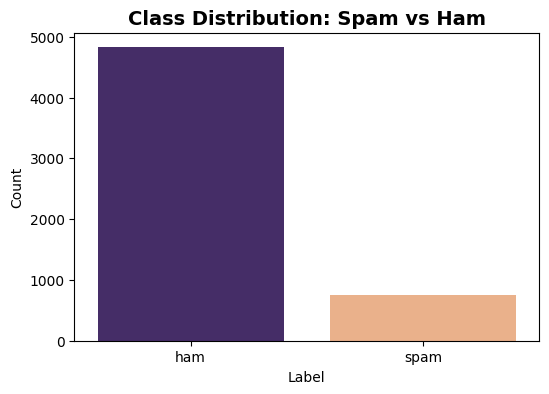

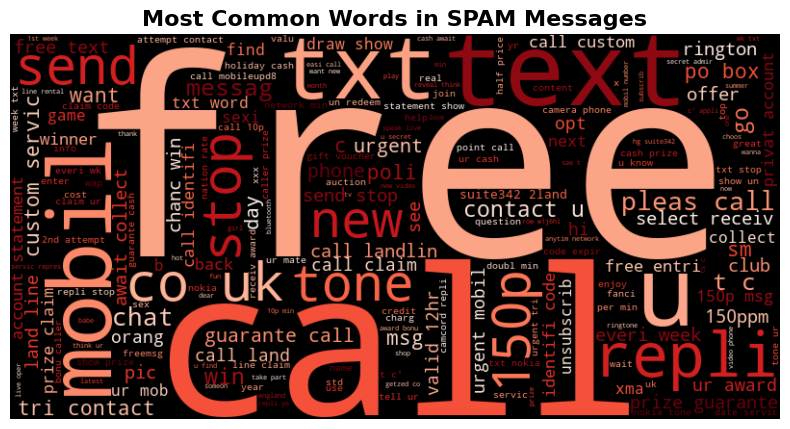

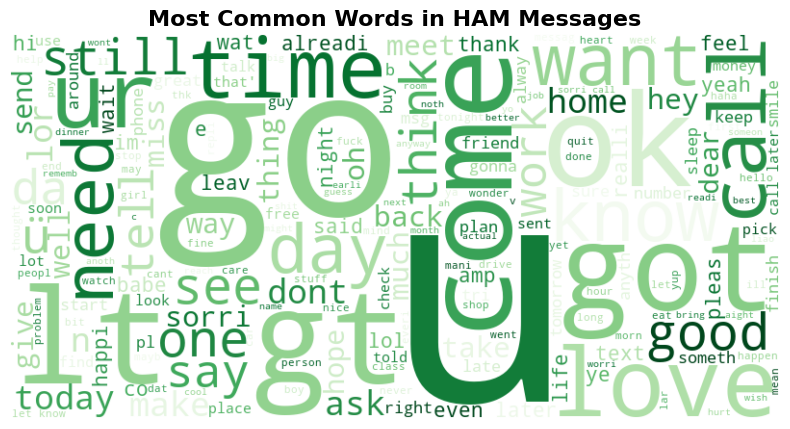

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Visualize the Class Distribution
plt.figure(figsize=(6, 4))
# Note: Using pandas Series mapping to silence newer seaborn deprecation warnings
sns.countplot(x=df['label'].tolist(), palette=['#432371',"#FAAE7B"])
plt.title("Class Distribution: Spam vs Ham", fontsize=14, fontweight='bold')
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# 2. Extract words for Spam and Ham
spam_words = " ".join(df[df['label'] == 'spam']['clean_message'])
ham_words = " ".join(df[df['label'] == 'ham']['clean_message'])

# 3. Create WordCloud for SPAM
spam_cloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(spam_words)
plt.figure(figsize=(10, 5))
plt.imshow(spam_cloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in SPAM Messages", fontsize=16, fontweight='bold')
plt.show()

# 4. Create WordCloud for HAM
ham_cloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(ham_words)
plt.figure(figsize=(10, 5))
plt.imshow(ham_cloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in HAM Messages", fontsize=16, fontweight='bold')
plt.show()


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# 1. Split the data (80% for training, 20% for testing)
# random_state=42 ensures we get the exact same random split every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Data: {X_train.shape[0]} emails")
print(f"Testing Data: {X_test.shape[0]} emails\n")

# 2. Initialize the Naive Bayes Model
mnb_model = MultinomialNB()

# 3. TRAIN THE MODEL! (This is where the magic happens)
mnb_model.fit(X_train, y_train)

print("✅ Model trained successfully!")


Training Data: 4457 emails
Testing Data: 1115 emails

✅ Model trained successfully!


In [9]:
# 1. Predict on the test dataset 
# (We will save 'y_pred' in memory so we can mathematically evaluate it in Step 6)
y_pred = mnb_model.predict(X_test)


# 2. Let's create a reusable function to predict custom text
def predict_email(email_text):
    # Step A: Clean the text
    cleaned_txt = clean_text(email_text)
    
    # Step B: Vectorize the text (convert to numbers)
    numerical_features = tfidf.transform([cleaned_txt]).toarray()
    
    # Step C: AI Prediction
    prediction = mnb_model.predict(numerical_features)[0]
    
    # Step D: Map 0 back to HAM and 1 back to SPAM
    return "🚨 SPAM" if prediction == 1 else "✅ HAM"


# 3. Test a normal email (HAM)
sample_ham = "Hey Bob, are we still meeting for lunch at 1 PM today?"
print(f"Message 1: {sample_ham}")
print(f"Prediction: {predict_email(sample_ham)}\n")

# 4. Test a suspicious email (SPAM)
sample_spam = "URGENT! You have won a $1,000 Walmart gift card. Text 'WIN' to 4455 to claim your prize!"
print(f"Message 2: {sample_spam}")
print(f"Prediction: {predict_email(sample_spam)}")


Message 1: Hey Bob, are we still meeting for lunch at 1 PM today?
Prediction: ✅ HAM

Message 2: URGENT! You have won a $1,000 Walmart gift card. Text 'WIN' to 4455 to claim your prize!
Prediction: 🚨 SPAM


In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- AI PERFORMANCE METRICS ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred) * 100:.2f}%")

print("\n--- RAW CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))


--- AI PERFORMANCE METRICS ---
Accuracy:  98.21%
Precision: 99.24%
Recall:    87.25%
F1-Score:  92.86%

--- RAW CONFUSION MATRIX ---
[[965   1]
 [ 19 130]]


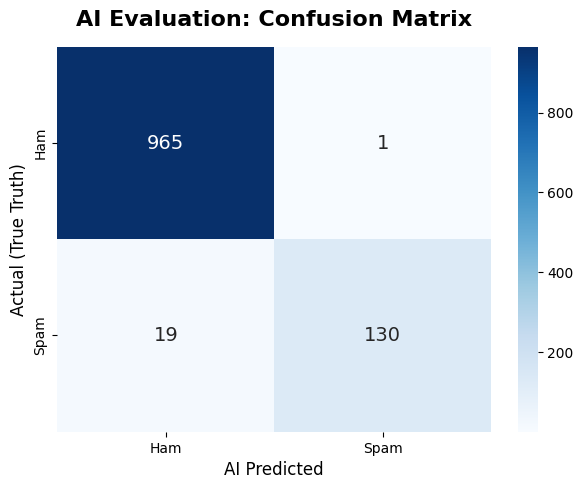

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Retrieve the raw confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set up the matplotlib figure
plt.figure(figsize=(7, 5))

# Plot the Heatmap
# fmt='d' ensures our numbers display as integers instead of scientific notation
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'],
            annot_kws={"size": 14}) # Make the numbers larger

plt.title('AI Evaluation: Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Actual (True Truth)', fontsize=12)
plt.xlabel('AI Predicted', fontsize=12)

plt.show()


In [13]:
import pickle
import os

# Ensure the models directory exists
os.makedirs('../models', exist_ok=True)

# 1. Save the trained Naive Bayes Model
with open('../models/spam_classifier.pkl', 'wb') as file:
    pickle.dump(mnb_model, file)

# 2. Save the TF-IDF Vectorizer (Crucial! The model is useless if we format new text differently)
with open('../models/tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

print("AI has been successfully saved to the /models directory!")


AI has been successfully saved to the /models directory!
